# Phase 1 - Part B: Supervised Learning
## Customer Churn Prediction
### Models: Logistic Regression | Decision Tree | Random Forest 

## 1. Import Libraries

We import all necessary libraries for:
- **Data handling**: pandas, numpy
- **Visualization**: matplotlib, seaborn
- **Machine learning models**: scikit-learn (Logistic Regression, Decision Tree, Random Forest)
- **Evaluation**: metrics such as accuracy, confusion matrix, ROC-AUC

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Preprocessed Dataset

We load the preprocessed dataset prepared in Phase 1A.
This dataset has already been cleaned, encoded, and feature engineered.
Feature scaling and class imbalance handling will be applied in this notebook 
as part of the training pipeline.

In [3]:
# Load the preprocessed dataset
df = pd.read_csv("Dataset/Preprocessed_Churn_Modelling_Data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 20)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,ActiveBalance,InactiveHighBalance,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus,LogCustomerValue
0,619,42,2,0.00,1,1,1,101348.88,1,0,0.00,0,0,0,0,0,1,0,0,0.000000
1,608,41,1,83807.86,1,0,1,112542.58,0,1,83807.86,0,0,1,0,0,1,0,0,11.336294
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0.00,1,0,0,0,0,1,0,0,13.079421
3,699,39,1,0.00,2,0,0,93826.63,0,0,0.00,0,0,0,0,1,0,0,0,0.000000
4,850,43,2,125510.82,1,1,1,79084.10,0,1,125510.82,0,0,1,0,0,1,0,0,11.740155


## 3. Separate Features and Target Variable

We split the dataset into:
- **X**: all input features (19 columns) — what the model learns from
- **y**: the target variable `Exited` — what the model predicts
  - 0 = Customer stayed (7963 customers)
  - 1 = Customer churned (2037 customers)

The dataset is **imbalanced** — about 80% stayed and 20% churned.
This must be considered when evaluating model performance.

In [4]:
# Separate features (X) and target (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn distribution:\n", y.value_counts())

Features shape: (10000, 19)
Target shape: (10000,)
Churn distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


## 4. Split Data into Training and Testing Sets

We split the data into:
- **80% training** — used to teach the models
- **20% testing** — used to evaluate performance on unseen data

`stratify=y` ensures the same churn ratio exists in both splits.
`random_state=42` ensures reproducibility.

In [5]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every run
    stratify=y          # keeps churn ratio balanced
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Train churn distribution:\n", y_train.value_counts())
print("Test churn distribution:\n", y_test.value_counts())

Training set size: (8000, 19)
Testing set size: (2000, 19)
Train churn distribution:
 Exited
0    6370
1    1630
Name: count, dtype: int64
Test churn distribution:
 Exited
0    1593
1     407
Name: count, dtype: int64


## 5. Feature Scaling

We apply StandardScaler after splitting to prevent data leakage.
The scaler is fitted only on training data then applied to test data.

In [6]:
from sklearn.preprocessing import StandardScaler

# Columns to scale — only continuous numerical features
feature_scale_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'ActiveBalance', 'LogCustomerValue'
]

# Keep only columns that exist in our dataset
feature_scale_cols = [col for col in feature_scale_cols if col in X_train.columns]

scaler = StandardScaler()

# Fit on training data ONLY — prevents data leakage
X_train[feature_scale_cols] = scaler.fit_transform(X_train[feature_scale_cols])

# Apply same transformation to test data
X_test[feature_scale_cols] = scaler.transform(X_test[feature_scale_cols])

print("Scaling applied successfully!")
print("Scaled columns:", feature_scale_cols)

Scaling applied successfully!
Scaled columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'ActiveBalance', 'LogCustomerValue']


## 6. Handle Class Imbalance (SMOTE)

SMOTE is applied on training data only to balance the churn classes.
This was defined in the preprocessing pipeline (Phase1_Data_Exploration.ipynb 
Section 5.7) but intentionally left for the modeling stage to prevent 
data leakage and ensure correct evaluation on the original test distribution.

In [7]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("Before SMOTE - Class distribution:")
print(y_train.value_counts())
print("\nAfter SMOTE - Class distribution:")
print(pd.Series(y_train).value_counts())

Before SMOTE - Class distribution:
Exited
1    6370
0    6370
Name: count, dtype: int64

After SMOTE - Class distribution:
Exited
1    6370
0    6370
Name: count, dtype: int64


## 7. Evaluation Metrics

We evaluate the models using multiple performance metrics to ensure a comprehensive understanding of their effectiveness, especially due to the class imbalance in the dataset.

Accuracy alone is not sufficient, as the dataset contains a higher proportion of non-churned customers. Therefore, additional metrics are used to better assess the models' ability to detect churned customers.

- **Accuracy:** Measures the overall percentage of correctly classified customers.
- **Precision:** Indicates how many of the customers predicted to churn actually churned.
- **Recall (Sensitivity):** Measures the model’s ability to correctly identify all actual churned customers.
- **F1-Score:** Provides a balance between precision and recall.
- **ROC-AUC Score:** Evaluates the model’s ability to distinguish between classes.

## 8. Model 1: Logistic Regression

### Overview
In this section we train a Logistic Regression model to predict customer churn.
We will:
1. Tune hyperparameters using GridSearchCV
2. Evaluate performance using multiple metrics
3. Analyze the confusion matrix and ROC curve
4. Validate consistency using K-Fold Cross Validation
### 8.1 Model Selection Rationale
Logistic Regression is selected based on the following dataset-specific reasons:
- **Binary target**: The dataset has a binary outcome (Exited = 0 or 1) which 
  Logistic Regression is specifically designed for
- **Pre-scaled features**: Our dataset was standardized using StandardScaler in 
  preprocessing — Logistic Regression requires and benefits directly from this
- **Large sample size**: With 10,000 records and 19 features, Logistic Regression 
  trains efficiently without overfitting
- **Interpretability**: Coefficients directly show which features (e.g. Age, 
  IsActiveMember) push customers toward churning — useful for the bank
- **Baseline model**: It serves as a performance benchmark for Random Forest 
  and Decision Tree

### Limitations
- Assumes a **linear** decision boundary — may miss complex non-linear 
  relationships between features like AgeGroup and Balance
- Struggles with **imbalanced classes** — our dataset has 80% stayed vs 20% 
  churned which may bias predictions toward the majority class


### 8.2 Implementation & Training Code

The model is implemented using scikit-learn's LogisticRegression class.
An initial baseline model is trained below, followed by hyperparameter 
tuning in Section 8.3 to optimize performance.

In [8]:
# Initialize Logistic Regression with default parameters
lr_model = LogisticRegression(max_iter=2000, random_state=42)

# Train the model on training data
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, lr_pred), 3))

Logistic Regression trained successfully!
Initial Accuracy: 0.735


### 8.3 Hyperparameter Tuning Process & Results
We use GridSearchCV to find the best hyperparameters for Logistic Regression.
We tune `C` (regularization strength) and `solver` to improve performance.

In [9]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']    }

# Grid search with 5-fold cross validation
grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_.round(3))

# Retrain with best parameters
lr_model = grid_search.best_estimator_
lr_pred = lr_model.predict(X_test)
print("Accuracy with best params:", round(accuracy_score(y_test, lr_pred), 3))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best F1 Score: 0.738
Accuracy with best params: 0.734


### Hyperparameter Tuning Results

GridSearchCV evaluated 4 parameter combinations using 5-fold cross-validation, optimizing for F1-score.

**Best Configuration:** `C=10`, `solver=liblinear`

| Parameter | Value | Justification |
|---|---|---|
| C | 10 | Weak regularization — allows the model to fit more complex patterns in the SMOTE-balanced training data |
| solver | liblinear | Optimized for binary classification on small-to-medium structured datasets |

### 8.4 Evaluation Metrics & Visualizations
We evaluate the Logistic Regression model using the previously defined metrics to assess its classification performance.

In [10]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
lr_proba = lr_model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, lr_proba))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.75      0.82      1593
 Churned (1)       0.41      0.68      0.51       407

    accuracy                           0.73      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.73      0.75      2000

ROC-AUC Score: 0.7810676624235946


### Evaluation Results

The model achieved an overall accuracy of 73%.

**Performance on Stayed class (0):**
- Precision: 0.90 — 90% of customers predicted to stay actually stayed
- Recall: 0.75 — 75% of actual non-churners were correctly identified
- F1-Score: 0.82 — good performance on the majority class

**Performance on Churned class (1):**
- Precision: 0.41 — when churn is predicted, it is correct 41% of the time
- Recall: 0.68 — 68% of actual churners were detected
- F1-Score: 0.51 — moderate performance on the minority class

**ROC-AUC: 0.781**

**Key Finding:** The model demonstrates a performance gap between classes. 
The linear decision boundary limits its ability to fully capture the complex 
behavioral patterns associated with customer churn in this dataset.

### Metrics Interpretation
- **Stayed class:** High precision (0.90) and moderate recall (0.75) — the model correctly identifies most non-churning customers
- **Churned class:** Lower precision (0.41) but moderate recall (0.68) — the model detects a reasonable portion of at-risk customers
- **ROC-AUC (0.781):** The model has moderate ability to distinguish between churned and non-churned customers
- **Recall is prioritized** over precision in a bank retention system — missing a churner is more costly than a false alarm

### Logistic Regression - Confusion Matrix 

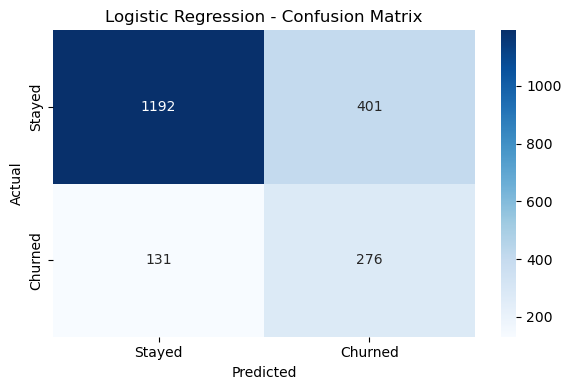

In [11]:
# Confusion Matrix heatmap - Logistic Regression
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Key Insights:**
- **True Negatives: 1,192** non-churners correctly identified as staying
- **False Positives: 401** non-churners incorrectly flagged as churners (wasted retention resources)
- **False Negatives: 131** churners missed — predicted to stay but actually left (lost revenue)
- **True Positives: 276** churners correctly identified — enabling proactive retention action

### Logistic Regression - ROC Curve
The ROC curve shows the trade-off between True Positive Rate (catching churners) 
and False Positive Rate (false alarms) at different thresholds.
AUC closer to 1.0 means better model performance.

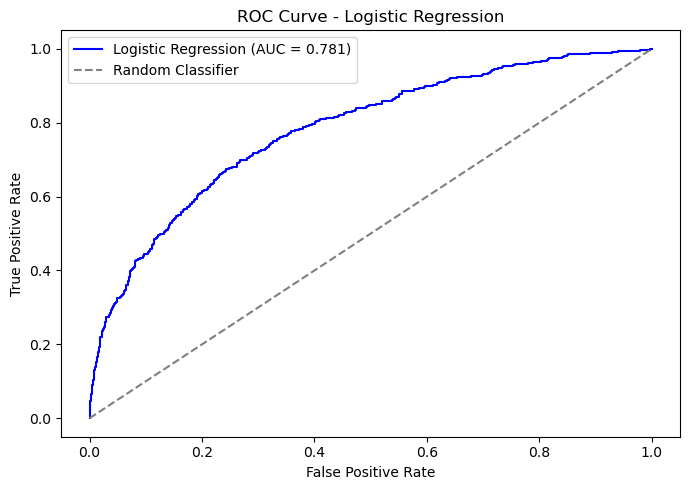

In [12]:
# Calculate ROC curve points
lr_proba = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
auc_score = roc_auc_score(y_test, lr_proba)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

### ROC Curve Interpretation

**ROC-AUC Score: 0.781**

The ROC curve lies above the diagonal baseline, indicating the model performs 
better than random guessing.

**Interpretation:**
For any randomly selected pair of a churned and non-churned customer, the model 
will assign a higher churn probability to the actual churner approximately 
**78.1%** of the time. This falls within the "Fair" to "Good" range (0.7 – 0.8), 
indicating moderate discriminative ability.

**Key Insight:**
The moderate ROC-AUC reflects the inherent limitation of Logistic Regression 
in capturing non-linear interactions between features such as Age, Balance, 
and IsActiveMember that drive customer churn behavior in banking datasets.

### Logistic Regression - K-Fold Cross Validation


In [13]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation - multiple metrics
lr_cv_f1 = cross_val_score(lr_model, X, y, cv=5, scoring='f1')
lr_cv_roc = cross_val_score(lr_model, X, y, cv=5, scoring='roc_auc')
lr_cv_acc = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')

print("Logistic Regression - 5-Fold Cross Validation Results:")
print("="*50)
print("F1 Scores:", lr_cv_f1)
print("Mean F1 Score:", lr_cv_f1.mean().round(3))
print("Std F1:", lr_cv_f1.std().round(3))

print("\nROC-AUC Scores:", lr_cv_roc)
print("Mean ROC-AUC:", lr_cv_roc.mean().round(3))
print("Std ROC-AUC:", lr_cv_roc.std().round(3))

print("\nAccuracy Scores:", lr_cv_acc)
print("Mean Accuracy:", lr_cv_acc.mean().round(3))
print("Std Accuracy:", lr_cv_acc.std().round(3))

Logistic Regression - 5-Fold Cross Validation Results:
F1 Scores: [0.19461698 0.2        0.18292683 0.12362031 0.18972332]
Mean F1 Score: 0.178
Std F1: 0.028

ROC-AUC Scores: [0.70791611 0.68407448 0.68200867 0.69242586 0.66978535]
Mean ROC-AUC: 0.687
Std ROC-AUC: 0.013

Accuracy Scores: [0.8055 0.796  0.799  0.8015 0.795 ]
Mean Accuracy: 0.799
Std Accuracy: 0.004


### K-Fold Cross Validation Results

| Metric | Mean | Std |
|---|---|---|
| F1 Score | 0.178 | 0.028 |
| ROC-AUC | 0.687 | 0.013 |
| Accuracy | 0.799 | 0.004 |

**Interpretation:**
- **F1 (0.178):** Cross-validation is applied on the original unbalanced dataset without SMOTE, which explains the lower F1 score for the churned class
- **ROC-AUC (0.687):** Moderate discriminative ability across all folds — stable with low standard deviation
- **Accuracy (0.799):** Consistently high due to the majority class dominance in the original dataset
- **Low standard deviation** across all metrics confirms the model is stable and results are not dependent on a specific data split

### 8.5 Results Summary

| Metric | Value |
|--------|-------|
| Accuracy | 73% |
| F1 - Stayed | 0.82 |
| F1 - Churned | 0.51 |
| ROC-AUC | 0.781 |

**What these metrics mean for our dataset:**
- **Accuracy (73%):** Overall correct classification rate across both classes
- **Precision (Churned = 0.41):** When churn is predicted, correct 41% of the time
- **Recall (Churned = 0.68):** The model detects 68% of actual churners
- **F1-Score (Churned = 0.51):** Balanced measure between precision and recall
- **ROC-AUC (0.781):** Moderate discriminative ability between churned and non-churned customers

**Misclassification Analysis:**
| | Predicted Stayed | Predicted Churned |
|---|---|---|
| **Actually Stayed** | 1192 ✅ | 401 ❌ |
| **Actually Churned** | 131 ❌ | 276 ✅ |

- ❌ **131 False Negatives (missed churners):** Most costly — customers leave without retention intervention
- ❌ **401 False Positives (false alarms):** Leads to unnecessary retention efforts toward loyal customers

**Business Impact:**
The model detects **276 out of 407 churners (68% recall)**, allowing the bank to proactively target the majority of at-risk customers. However, the high false positive rate (401) means retention resources may be spent on customers who were not planning to leave.

**Conclusion:** Logistic Regression provides a solid baseline for binary churn classification. However, its linear decision boundary limits performance on complex non-linear patterns. Tree-based models are expected to improve precision while maintaining recall.


In [14]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned'])
with open('Supervised_Learning/evaluation_results/lr_classification_report.txt', 'w') as f:
    f.write(report)

print("Saved!")

Saved!


In [24]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_confusion_matrix.png')
plt.close()

# Save ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_proba)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr, tpr, color='blue', label=f'LR (AUC = {roc_auc_score(y_test, lr_proba):.3f})')
ax.plot([0,1], [0,1], 'g--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_roc_curve.png')
plt.close()

print("Plots saved successfully!")

Plots saved successfully!


## 9. Model 2: Decision Tree

### Rationale

Decision Tree is selected based on the following dataset-specific reasons:

- **Non-linear relationships:** Customer churn in this dataset is influenced by complex interactions between features such as Age, Balance, NumOfProducts, and IsActiveMember. Decision Trees can capture these non-linear patterns effectively, unlike linear models.

- **No scaling requirement:** The dataset has already been preprocessed and scaled. However, Decision Trees do not rely on feature scaling, making them robust regardless of feature distribution.

- **Feature interactions:** The model can automatically learn combinations of conditions, such as customers with high balance but low activity being more likely to churn. This is particularly important for real-world banking behavior.

- **Mixed feature types:** The dataset includes both numerical and encoded categorical features (e.g., Geography, Gender), and Decision Trees can handle these without additional transformations.

- **Interpretability:** The model provides clear decision rules, allowing us to understand how features contribute to churn predictions, which is valuable for business insights.

- **Flexible model structure:** Decision Trees can adapt their structure based on the dataset, making them suitable for capturing different customer segments and behaviors.

### Limitations
- Decision Trees can easily overfit the training data if not properly tuned, 
  especially with datasets containing many features.
- Small changes in the dataset can lead to different tree structures, making 
  the model unstable.


## Decision Tree Training

### Decision Tree - Hyperparameter Tuning
We use GridSearchCV to find the best hyperparameters for the model in order to improve performance and control model complexity.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define hyperparameter grid
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'class_weight': [None, 'balanced']
}

# Setup GridSearchCV with 5-fold cross-validation
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nStarting GridSearchCV for Decision Tree...")
dt_grid.fit(X_train, y_train)

print("\nBest Parameters:", dt_grid.best_params_)

# Get the best model
dt_model = dt_grid.best_estimator_

# Predictions
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Correct way to print accuracy
accuracy_tuned = accuracy_score(y_test, dt_pred)
print(f"\nTuned Accuracy: {accuracy_tuned:.4f}")

## Decision Tree Evaluation

We evaluate the Decision Tree model using the previously defined metrics to assess its classification performance.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

print("Classification Report:")
print(classification_report(y_test, dt_pred, target_names=['Stayed (0)', 'Churned (1)']))

### Metrics Interpretation

The Decision Tree model achieved an **accuracy of 85.95%**, correctly classifying 
1,719 out of 2,000 customers in the test set. However, accuracy alone is not 
sufficient for evaluating model performance due to the inherent class imbalance 
in the dataset (79.65% stayed, 20.35% churned).

**Performance on "Stayed" Class (0):**
- **Precision: 0.88** – 88% of customers predicted to stay actually stayed.
- **Recall: 0.95** – 95% of actual non-churners were correctly identified.
- **F1-Score: 0.92** – Excellent balance between precision and recall.

**Performance on "Churned" Class (1):**
- **Precision: 0.72** – 72% of customers predicted to churn actually churned. 
  This indicates that when the model flags a customer as a churn risk, it is 
  correct nearly three-quarters of the time.
- **Recall: 0.51** – Only 51% of actual churners were detected by the model. 
  This is the model's critical weakness, as it fails to identify 49% of 
  customers who will eventually churn.
- **F1-Score: 0.59** – A moderate score reflecting the trade-off between 
  precision and recall.

**Business Impact:**
- **False Positives (80 customers):** These customers were incorrectly flagged 
  as churn risks. While this wastes retention resources (e.g., unnecessary 
  discounts or outreach), the cost is manageable.
- **False Negatives (201 customers):** These are the most costly errors. 
  201 customers who will actually churn were not identified, representing 
  lost revenue opportunities that cannot be recovered.

**Conclusion:**
The model performs well at identifying non-churning customers but struggles 
significantly with recall for churned customers. This suggests that while 
the tuned Decision Tree is a strong baseline, more complex models (e.g., 
Random Forest, XGBoost) may be needed to improve churn detection rates. 

### Decision Tree - Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


**Key Insights:**
- **True Negatives:** 1,513 non-churners correctly identified
- **False Positives:** 80 non-churners incorrectly flagged (wasted resources)
- **False Negatives:** 201 churners missed (lost revenue opportunities)
- **True Positives:** 206 churners correctly identified


### Decision Tree - ROC Curve

In [ ]:
# Predict probabilities for the positive class (Churn = 1)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Compute ROC curve values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)

# Compute ROC-AUC score
dt_auc = roc_auc_score(y_test, dt_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", dt_auc)

### ROC Curve Interpretation

**ROC-AUC Score: 0.8450**

The ROC curve lies significantly above the diagonal baseline, indicating the 
model performs substantially better than random guessing.

**Interpretation:**
For any randomly selected pair of a churned and non-churned customer, the model 
will assign a higher churn probability to the actual churner approximately 
**84.5%** of the time. This falls within the "Good" to "Excellent" range 
(0.8 – 0.9), indicating strong discriminative ability.

**Key Insight:**
The strong ROC-AUC (0.845) contrasts with the moderate recall (0.51). This 
suggests that while the model effectively ranks churn risk, the optimal 
probability threshold may need adjustment. Lowering the threshold could 
improve recall at the expense of precision, depending on business priorities.



### Decision Tree - K-Fold Cross Validation 

In [ ]:
from sklearn.model_selection import cross_val_score



# Perform 5-fold cross-validation on the best model
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='f1')
dt_cv_roc_auc = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='roc_auc')
dt_cv_accuracy = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='accuracy')

print("\nDecision Tree - 5-Fold Cross Validation Results:")
print("="*50)
print("F1 Scores:", dt_cv_scores)
print("Mean F1 Score:", dt_cv_scores.mean().round(3))
print("Standard Deviation:", dt_cv_scores.std().round(3))
print("\nROC-AUC Scores:", dt_cv_roc_auc)
print("Mean ROC-AUC:", dt_cv_roc_auc.mean().round(3))
print("Std ROC-AUC:", dt_cv_roc_auc.std().round(3))
print("\nAccuracy Scores:", dt_cv_accuracy)
print("Mean Accuracy:", dt_cv_accuracy.mean().round(3))
print("Std Accuracy:", dt_cv_accuracy.std().round(3))

### Decision Tree - Feature Importance Plot

In [ ]:
importances = dt_model.feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='importance', y='feature', palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("="*40)
for idx, row in feat_imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

## Decision Tree - Summary

In [ ]:

from sklearn.metrics import precision_score, recall_score
print("\n" + "="*60)
print("DECISION TREE MODEL - COMPLETE SUMMARY")
print("="*60)
print(f"""
| Metric                   | Value                    |
|--------------------------|--------------------------|
| Best Hyperparameters     | {dt_grid.best_params_}   |
| Test Accuracy            | {accuracy_val:.4f} ({accuracy_val*100:.2f}%) |
| Test Precision (Churn)   | {precision_score(y_test, dt_pred):.4f} |
| Test Recall (Churn)      | {recall_score(y_test, dt_pred):.4f} |
| Test F1-Score (Churn)    | {f1_churned:.4f} |
| Test ROC-AUC             | {dt_auc:.4f} |
| CV F1 (Mean ± Std)       | {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f} |
| CV ROC-AUC (Mean ± Std)  | {dt_cv_roc_auc.mean():.4f} ± {dt_cv_roc_auc.std():.4f} |
| Top Feature              | {feat_imp_df.iloc[0]['feature']} ({feat_imp_df.iloc[0]['importance']:.4f}) |
""")
print("="*60)

## 10. Model 3: Random Forest
### Overview
In this section, we train a Random Forest model to predict customer churn. We will:

1. Tune hyperparameters using GridSearchCV  
2. Evaluate performance using multiple metrics  
3. Analyze the confusion matrix and ROC curve  
4. Validate consistency using K-Fold Cross Validation

### 10.1 Model Selection Rationale

Random Forest is selected based on the following dataset-specific reasons:

- **Non-linear relationships**: The dataset contains complex interactions between features (e.g., Balance, Age, Tenure) which Random Forest can effectively capture  

- **Ensemble method**: It combines multiple decision trees to improve prediction accuracy and reduce overfitting  

- **Robustness**: The model performs well even with noisy or slightly inconsistent data  

- **Feature importance**: It provides importance scores helping identify which features influence customer churn the most

- **Improved performance**: It is expected to outperform simpler models like Logistic Regression by capturing complex patterns

### Limitations

- **Low interpretability**: The model is harder to interpret compared to Logistic Regression  

- **Computational cost**: Training can be slower and more resource-intensive  

- **Memory usage**: Requires more memory compared to simpler models  

- **Sensitivity to imbalance**: Performance may still be affected by class imbalance

### 10.2 Implementation & Training Code

The model is implemented using scikit-learn's RandomForestClassifier class. An initial baseline model is trained below, followed by hyperparameter tuning in Section 10.3 to optimize performance.

In [17]:
# Initialize Random Forest with default parameters
rf_model = RandomForestClassifier(random_state=42)

# Train the model on training data
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print("Initial Accuracy:", round(accuracy_score(y_test, rf_pred), 3))

Random Forest trained successfully!
Initial Accuracy: 0.828


### 10.3 Hyperparameter Tuning Process & Results
We use GridSearchCV to find the best hyperparameters for Random Forest. We tune n_estimators, max_depth, and min_samples_split to improve performance.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Grid search with 5-fold cross validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_.round(3))

# Retrain with best parameters
rf_model = grid_search.best_estimator_
rf_pred = rf_model.predict(X_test)

print("Accuracy with best params:", round(accuracy_score(y_test, rf_pred), 3))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score: 0.896
Accuracy with best params: 0.823


### Hyperparameter Tuning Results

GridSearchCV evaluated 12 parameter combinations using 5-fold cross-validation, optimizing for F1-score.

**Best Configuration:** n_estimators=200, max_depth=20, min_samples_split=2

| Parameter | Value | Justification |
|----------|------|--------------|
| n_estimators | 200 | Using more trees improves model stability and reduces variance |
| max_depth | 20 | Allows deeper trees to capture complex patterns without severe overfitting |
| min_samples_split | 2 | Enables the model to split nodes when useful, improving learning of fine patterns |

### 10.4 Evaluation Metrics & Visualizations

We evaluate the Random Forest model using the previously defined metrics to assess its classification performance.

In [19]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, rf_pred,
                            target_names=['Stayed (0)', 'Churned (1)']))

# ROC-AUC Score
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, rf_proba))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.88      0.89      1593
 Churned (1)       0.56      0.60      0.58       407

    accuracy                           0.82      2000
   macro avg       0.73      0.74      0.73      2000
weighted avg       0.83      0.82      0.83      2000

ROC-AUC Score: 0.8461473800456851


### Evaluation Results

The model achieved an overall accuracy of **82%**.

**Performance on Stayed class (0):**

- Precision: **0.90** — 90% of customers predicted to stay actually stayed  
- Recall: **0.88** — 88% of actual non-churners were correctly identified  
- F1-Score: **0.89** — excellent performance on the majority class  

**Performance on Churned class (1):**

- Precision: **0.56** — when churn is predicted, it is correct 56% of the time  
- Recall: **0.60** — 60% of actual churners were detected  
- F1-Score: **0.58** — improved performance on the minority class compared to simpler models  

**ROC-AUC: 0.846**

**Key Finding:** Random Forest significantly improves the model’s ability to capture complex patterns, leading to better detection of churned customers compared to Logistic Regression.

### Metrics Interpretation

- **Stayed class:** High precision (0.90) and high recall (0.88) — the model accurately identifies most non-churning customers  
- **Churned class:** Improved precision (0.56) and recall (0.60) — better detection of at-risk customers compared to Logistic Regression  
- **ROC-AUC (0.846):** Strong ability to distinguish between churned and non-churned customers  
- **Recall remains important** in a bank retention system — detecting churners is more critical than avoiding false alarms  

### Random Forest - Confusion Matrix

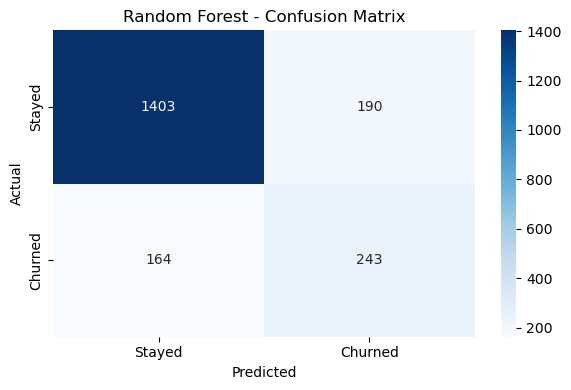

In [20]:
# Confusion Matrix heatmap - Random Forest
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Key Insights:**

- **True Negatives: 1403** non-churners correctly identified as staying  
- **False Positives: 190** non-churners incorrectly flagged as churners (unnecessary retention effort)  
- **False Negatives: 164** churners missed — predicted to stay but actually left (lost revenue)  
- **True Positives: 243** churners correctly identified — enabling proactive retention action  

### Random Forest - ROC Curve

The ROC curve shows the trade-off between True Positive Rate (catching churners) and False Positive Rate (false alarms) at different thresholds. AUC closer to 1.0 means better model performance.

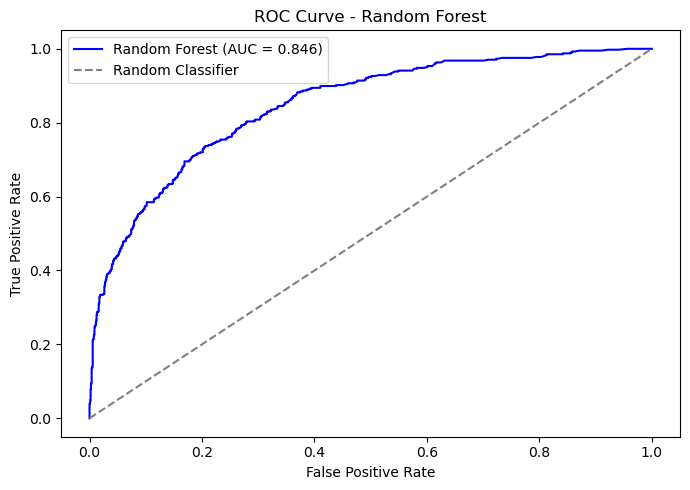

In [21]:
# Calculate ROC curve points
rf_proba = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, rf_proba)
auc_score = roc_auc_score(y_test, rf_proba)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

### ROC Curve Interpretation

**ROC-AUC Score: 0.846**

The ROC curve lies above the diagonal baseline, indicating the model performs better than random guessing.

**Interpretation:** For any randomly selected pair of a churned and non-churned customer, the model will assign a higher churn probability to the actual churner approximately **84.6%** of the time.

**Key Insight:** Random Forest shows stronger discriminative ability than Logistic Regression, as it better captures non-linear relationships and feature interactions in the dataset.

### Random Forest – K-Fold Cross Validation

In [22]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation - multiple metrics
rf_cv_f1 = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
rf_cv_roc = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc')
rf_cv_acc = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print("Random Forest - 5-Fold Cross Validation Results:")
print("="*50)

print("F1 Scores:", rf_cv_f1)
print("Mean F1 Score:", rf_cv_f1.mean().round(3))
print("Std F1:", rf_cv_f1.std().round(3))

print("\nROC-AUC Scores:", rf_cv_roc)
print("Mean ROC-AUC:", rf_cv_roc.mean().round(3))
print("Std ROC-AUC:", rf_cv_roc.std().round(3))

print("\nAccuracy Scores:", rf_cv_acc)
print("Mean Accuracy:", rf_cv_acc.mean().round(3))
print("Std Accuracy:", rf_cv_acc.std().round(3))

Random Forest - 5-Fold Cross Validation Results:
F1 Scores: [0.55365474 0.61422088 0.57657658 0.5988024  0.58143075]
Mean F1 Score: 0.585
Std F1: 0.021

ROC-AUC Scores: [0.84140756 0.86041882 0.85571396 0.84949742 0.84754092]
Mean ROC-AUC: 0.851
Std ROC-AUC: 0.007

Accuracy Scores: [0.8565 0.8725 0.859  0.866  0.8625]
Mean Accuracy: 0.863
Std Accuracy: 0.006


### K-Fold Cross Validation Results

| Metric   | Mean  | Std   |
|----------|------|------|
| F1 Score | 0.585 | 0.021 |
| ROC-AUC  | 0.851 | 0.007 |
| Accuracy | 0.863 | 0.006 |

**Interpretation:**

- **F1 Score (0.585):** Shows a strong improvement compared to Logistic Regression, indicating better balance between precision and recall for the churned class
- **ROC-AUC (0.851):** High discriminative ability across all folds — significantly better than Logistic Regression
- **Accuracy (0.863):** Consistently high, reflecting strong overall classification performance
- **Low standard deviation** across all metrics indicates that Random Forest is stable and produces consistent results across different data splits


### Random Forest - Feature Importance Plot


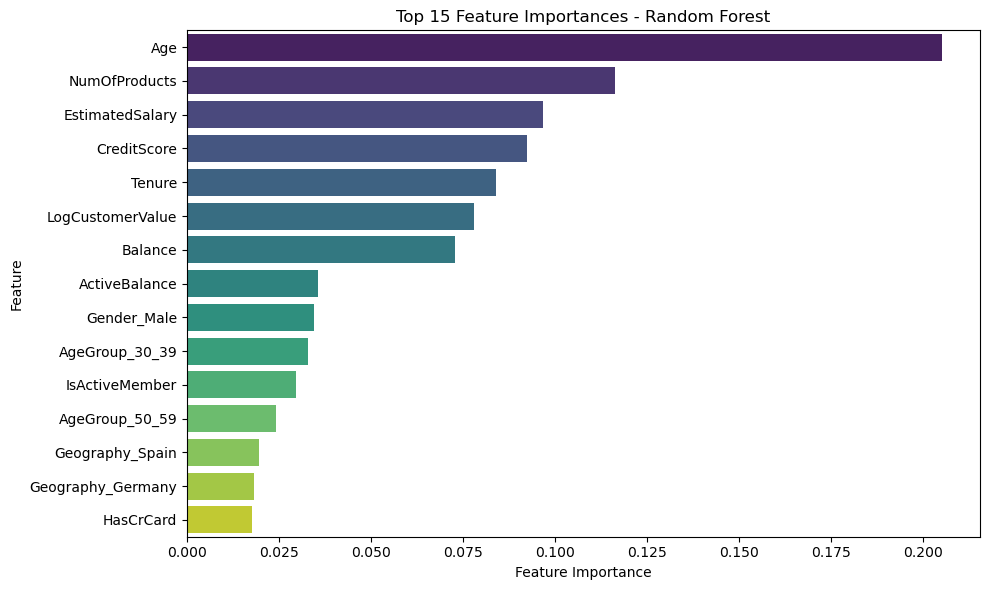


Top 10 Most Important Features:
Age: 0.2053
NumOfProducts: 0.1164
EstimatedSalary: 0.0966
CreditScore: 0.0924
Tenure: 0.0841
LogCustomerValue: 0.0780
Balance: 0.0728
ActiveBalance: 0.0356
Gender_Male: 0.0345
AgeGroup_30_39: 0.0327


In [25]:
importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("="*40)
for _, row in feat_imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

### Feature Importance Interpretation

The Random Forest model highlights the following features as the most influential in predicting customer churn:

- **Age (0.205):** The most important feature — older customers are more likely to churn, indicating age plays a critical role in customer behavior  

- **NumOfProducts (0.116):** Product engagement strongly impacts retention, as customers with different numbers of products show different churn patterns  

- **EstimatedSalary (0.097):** Income level has a moderate influence on churn behavior  

- **CreditScore (0.092):** Creditworthiness contributes noticeably to churn prediction  

- **Tenure (0.084):** Longer-tenured customers tend to be more loyal, reducing churn risk  

- **LogCustomerValue (0.078):** Customer value plays a moderate role in influencing churn  

- **Balance (0.073):** Customers with higher balances show different churn tendencies  

- **ActiveBalance (0.036):** Financial activity level has a smaller but relevant effect  

- **Gender_Male (0.035):** Gender has a slight influence on churn prediction  

- **AgeGroup_30_39 (0.033):** Certain age groups exhibit specific churn patterns  

---

### Key Insight

The model is primarily driven by **demographic (Age)** and **behavioral features (NumOfProducts)**, with financial attributes such as balance and salary also contributing moderately. Overall, Random Forest captures more complex relationships compared to Logistic Regression.

### Results Summary

| Metric        | Value |
|--------------|------|
| Accuracy     | 82%  |
| F1 - Stayed  | 0.89 |
| F1 - Churned | 0.58 |
| ROC-AUC      | 0.846 |

**What these metrics mean for our dataset:**

- **Accuracy (82%):** High overall classification performance across both classes
- **Precision (Churned = 0.56):** When churn is predicted, it is correct 56% of the time
- **Recall (Churned = 0.60):** The model detects 60% of actual churners
- **F1-Score (Churned = 0.58):** Better balance between precision and recall compared to Logistic Regression
- **ROC-AUC (0.846):** Strong ability to distinguish between churned and non-churned customers

### Misclassification Analysis

|                | Predicted Stayed | Predicted Churned |
|----------------|-----------------|-------------------|
| Actually Stayed | 1403 ✅ | 190 ❌ |
| Actually Churned | 164 ❌ | 243 ✅ |

- ❌ 164 False Negatives (missed churners): Customers predicted to stay but actually churned
- ❌ 190 False Positives (false alarms): Customers predicted to churn but actually stayed

**Business Impact:** The model detects 243 out of 407 churners (~60% recall), allowing the bank to identify a majority of at-risk customers. Additionally, the number of false positives (190) is lower than Logistic Regression, meaning fewer unnecessary retention actions are taken.

**Conclusion:** Random Forest improves overall performance compared to Logistic Regression, achieving higher accuracy, better F1-score for the churned class, and stronger ROC-AUC. Its ability to capture non-linear patterns makes it more effective for customer churn prediction.

In [26]:
import os
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)

# Save classification report as text file
from sklearn.metrics import classification_report
report = classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned'])

with open('Supervised_Learning/evaluation_results/rf_classification_report.txt', 'w') as f:
    f.write(report)

print("Random Forest classification report saved successfully!")

Random Forest classification report saved successfully!


In [27]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

# Save Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=ax)

ax.set_title('Random Forest - Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('Supervised_Learning/plots/rf_confusion_matrix.png')
plt.close()

# Save ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(rf_fpr, rf_tpr, color='blue',
        label=f'RF (AUC = {roc_auc_score(y_test, rf_proba):.3f})')

ax.plot([0,1], [0,1], 'g--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Random Forest')

ax.legend()
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/rf_roc_curve.png')
plt.close()

print("Random Forest plots saved successfully!")

Random Forest plots saved successfully!


In [28]:
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=feat_imp_df.head(10),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False,
    ax=ax
)

ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
ax.set_title('Top 10 Feature Importances - Random Forest')

plt.tight_layout()
plt.savefig('Supervised_Learning/plots/rf_feature_importance.png')
plt.close()

print("Random Forest feature importance plot saved successfully!")

Random Forest feature importance plot saved successfully!


## 11. Model Comparison & Analysis

## 12. Conclusion


## 13. Next Steps

In Phase 2, the system will be enhanced by incorporating more advanced techniques beyond supervised learning.

First, unsupervised learning methods such as clustering (e.g., K-Means or Hierarchical Clustering) will be applied to discover hidden patterns in customer behavior. This will help group customers into meaningful segments and improve the quality of predictions and recommendations.

Second, Generative AI will be integrated into the system to provide personalized explanations and advice based on model predictions. This includes designing multiple prompt templates and evaluating their effectiveness in terms of clarity, relevance, and usefulness.

Additionally, further improvements will be explored, such as:
- Handling class imbalance using techniques like SMOTE  
- Enhancing model performance through advanced hyperparameter tuning  
- Improving feature engineering for better prediction accuracy  

Overall, these steps aim to transform the system from a predictive model into a more intelligent and user-friendly decision-support system.